In [9]:
import pandas as pd
from pandasql import sqldf

In [10]:
# Load the student performance data into a pandas DataFrame
students = pd.read_csv('/content/student_performance.csv')
display(students.head())

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [12]:
# Question 1: Write a SQL query to find the average programming score for female students onl
sql_query = """
SELECT
    ROUND(AVG(programming_score), 1) AS avg_programming_score
FROM students
WHERE gender = 'Female';
"""

avg_score_female = sqldf(sql_query)
display(avg_score_female)

,avg_programming_score
0,70.2


In [14]:
#Question 2: What is the difference between WHERE and HAVING? Write one example of each using the students table.


# WHERE filters individual rows before grouping
sql_query = """
SELECT *
FROM students
WHERE math_score > 80;
"""
high_math_students = sqldf(sql_query)
display(high_math_students)


# HAVING filters grouped data after GROUP BY
sql_query = """
SELECT
    department,
    AVG(math_score) AS avg_math_score
FROM students
GROUP BY department
HAVING AVG(math_score) > 75;
"""
avg_math_department = sqldf(sql_query)
display(avg_math_department)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
2,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
3,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023
4,1013,Suresh Rao,21,Male,Computer Science,2,83,86,77,88,88,Mysore,2023
5,1016,Ritu Agarwal,20,Female,Electronics,2,87,83,86,69,93,Agra,2023
6,1018,Swati Kulkarni,19,Female,Computer Science,2,90,87,85,92,94,Nagpur,2023
7,1022,Tanvi Mehta,19,Female,Computer Science,2,93,90,88,96,97,Surat,2023
8,1025,Amit Bose,19,Male,Computer Science,2,86,82,79,89,91,Kolkata,2023
9,1027,Gaurav Shukla,21,Male,Computer Science,2,84,79,75,87,87,Lucknow,2023


,department,avg_math_score
0,Computer Science,85.615385


In [15]:
#Question 3: Write a SQL query to find all departments where the average attendance is above 85%.

sql_query = """
SELECT
    department,
    ROUND(AVG(attendance_percentage), 1) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""
high_attendance_departments = sqldf(sql_query)
display(high_attendance_departments)

,department,avg_attendance
0,Computer Science,90.7


In [18]:
# Question 4: What does pd.read_sql_query() return? What two arguments does it require?

sql_query = "SELECT * FROM students"
students_df = sqldf(sql_query)
display(students_df)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


,department,avg_programming_score
0,Computer Science,89.2
1,Electronics,61.5
2,Mechanical,49.3
3,Civil,40.6


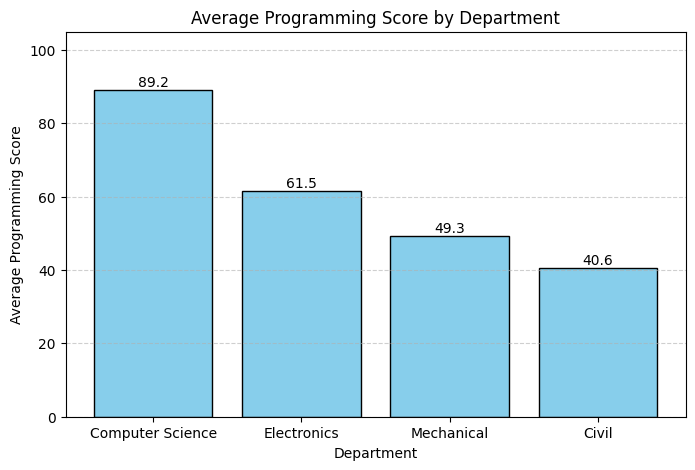

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pandasql import sqldf

sql_query = """
SELECT
    department,
    ROUND(AVG(programming_score), 1) AS avg_programming_score
FROM students
GROUP BY department
ORDER BY avg_programming_score DESC;
"""

avg_programming_df = sqldf(sql_query)
display(avg_programming_df)
plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_programming_df["department"],
    avg_programming_df["avg_programming_score"],
    color="skyblue",
    edgecolor="black"
)

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Programming Score")
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height}",
        ha='center'
    )

plt.show()